# 12 — Explainability (Phase 5a)

**Goal:** answer *"why did the model decide that?"* for both halves of BehaviorDNA, on **real GTA data**:

1. **Identification (LightGBM)** — exact **SHAP** values: which behavioural features drive *who* the model thinks you are. We dig into the hardest, most honest case: telling two players apart on **identical hardware**.
2. **Cheat detection (LSTM autoencoder)** — **per-channel reconstruction-error attribution**: when the autoencoder flags a chunk as cheat-like, *which of the 8 raw input channels* (mouse dx/dy, clicks, keys, …) reconstructed poorly and drove the flag.

> Why two different techniques? SHAP is exact and fast for trees. Running SHAP *through* an LSTM is fragile, and we don't need it: the autoencoder's own reconstruction error already decomposes cleanly per channel, which is a more robust and more directly interpretable explanation.

The reusable logic lives in `pipeline/explainability.py` (unit-tested in `tests/test_explainability.py`); this notebook is the narrated walkthrough.

In [1]:
import json
import pickle
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from pipeline.explainability import (
    CHANNEL_NAMES,
    mean_abs_shap,
    per_channel_reconstruction_error,
    tree_shap,
)
from pipeline.features.run import FEATURE_COLS

FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

artifact = pickle.load(open(ROOT / "models" / "model.pkl", "rb"))
model, scaler, le = artifact["model"], artifact["scaler"], artifact["label_encoder"]
classes = list(le.classes_)
print("Identification model:", artifact["model_type"], "| players:", classes)
print("Model carries real feature names:", list(model.feature_names_in_[:3]), "…")

Identification model: lightgbm | players: ['dninix', 'hydra', 'shotik']
Model carries real feature names: [np.str_('speed_mean'), np.str_('speed_std'), np.str_('accel_mean')] …


## Part 1 — Global SHAP for player identification

SHAP assigns every feature a signed contribution to each prediction, with the guarantee that the contributions sum to the model's output (minus a baseline). Averaging the **absolute** SHAP value of a feature over many windows gives a principled global importance — *per player*, since each player is a separate output class.

We explain the model on the held-out **test** split (windows it never trained on), scaled exactly as in production (named frame → SHAP shows real feature names).

In [2]:
test = pd.read_parquet(ROOT / "data" / "splits" / "test.parquet")
X_test = scaler.transform(test[FEATURE_COLS].fillna(0.0))  # named DataFrame
explanation = tree_shap(model, X_test)
print("SHAP values shape (samples, features, classes):", explanation.values.shape)

imp = mean_abs_shap(explanation.values, FEATURE_COLS, classes)
imp = imp.loc[imp.sum(axis=1).sort_values(ascending=False).index]  # most important first
imp.head(10).round(3)

SHAP values shape (samples, features, classes): (34, 25, 3)


,dninix,hydra,shotik
speed_mean,1.135,0.170,4.780
accel_std,0.881,0.434,1.757
click_interval_std,1.320,0.634,0.000
burst_rate,0.280,0.580,0.703
event_rate,0.519,0.856,0.023
keystroke_periodicity,0.717,0.615,0.025
wasd_rhythm,0.485,0.653,0.171
accel_mean,0.223,0.143,0.925
mouse_key_ratio,0.701,0.444,0.028
click_interval_mean,0.279,0.741,0.001


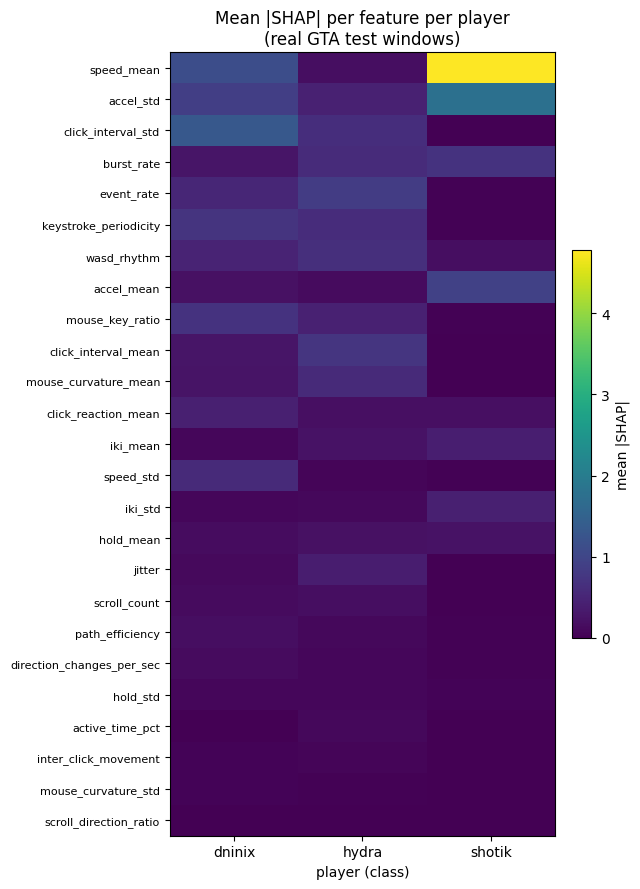

In [3]:
# Per-player feature-importance heatmap
fig, ax = plt.subplots(figsize=(6.5, 9))
im = ax.imshow(imp.values, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes)
ax.set_xlabel("player (class)")
ax.set_title("Mean |SHAP| per feature per player\n(real GTA test windows)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="mean |SHAP|")
fig.tight_layout()
fig.savefig(FIG / "phase5a_shap_importance_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

**Reading it:** bright rows are the features the identification model leans on most; the column pattern shows that different players are recognised by different behavioural signatures (a per-player *fingerprint*, not one global ranking). Mouse-kinematic and trajectory features tend to dominate — these are the sens/DPI-normalised speed/acceleration/curvature signals.

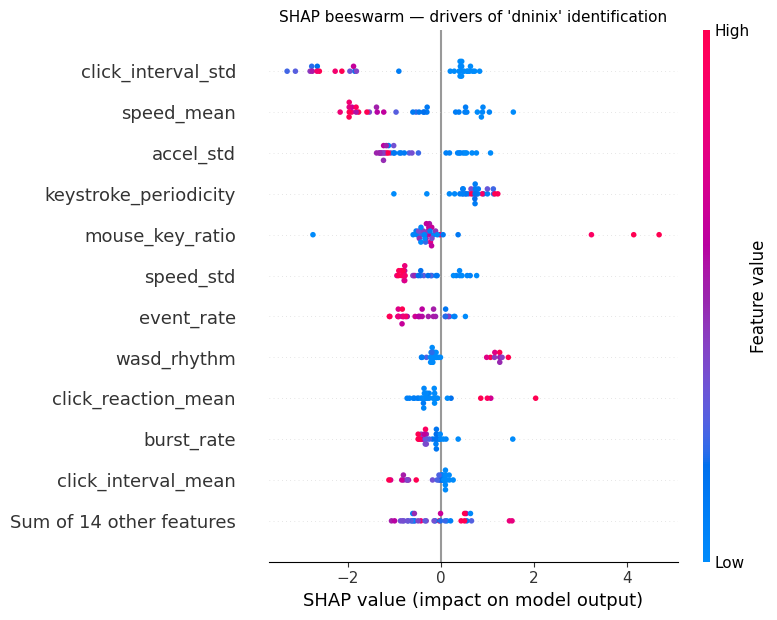

In [4]:
# Beeswarm: the distribution of SHAP values for the first player's class
cls_idx = 0
shap.plots.beeswarm(explanation[:, :, cls_idx], max_display=12, show=False)
plt.title(f"SHAP beeswarm — drivers of '{classes[cls_idx]}' identification", fontsize=11)
plt.tight_layout()
plt.savefig(FIG / "phase5a_beeswarm.png", dpi=110, bbox_inches="tight")
plt.show()

## Part 2 — "Why was *this* window attributed to this player?"

A waterfall plot decomposes a **single** prediction: it starts at the model's baseline log-odds for a class and adds each feature's SHAP contribution until it reaches this window's score. This is the per-decision audit trail an anti-cheat reviewer would want.

Window 0: true=shotik  predicted=shotik


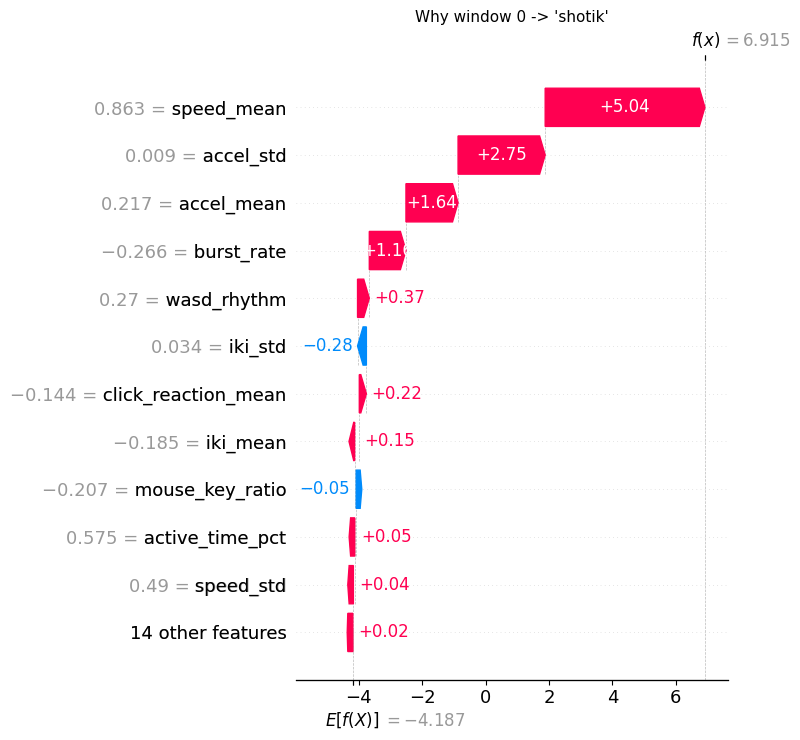

In [5]:
y_pred = model.predict(X_test)
i = 0  # first test window
pred_idx = int(y_pred[i])
print(f"Window {i}: true={test['player'].iloc[i]}  predicted={classes[pred_idx]}")
shap.plots.waterfall(explanation[i, :, pred_idx], max_display=12, show=False)
plt.title(f"Why window {i} -> '{classes[pred_idx]}'", fontsize=11)
plt.tight_layout()
plt.savefig(FIG / "phase5a_waterfall.png", dpi=110, bbox_inches="tight")
plt.show()

## Part 3 — Same-hardware deep-dive: hydra vs dninix

This is the honest, hardest test. **hydra and dninix were recorded on the same PC with identical game settings** — only the human differs. Telling them apart can't lean on any hardware artefact (DPI, polling, OS), so whatever SHAP highlights here is *pure behavioural signal*.

We train a 2-class model on just those two players (same player-stratified split + LightGBM as the pipeline) and SHAP it.

In [6]:
import yaml

from pipeline.features.split import split
from pipeline.training.run import train_lightgbm

cfg = yaml.safe_load(open(ROOT / "configs" / "training.yaml"))
feats = pd.read_parquet(ROOT / "data" / "processed" / "features.parquet")
pair = feats[feats["player"].isin(["hydra", "dninix"])].copy()
tr, va, te = split(
    pair,
    cfg["data"]["test_size"],
    cfg["data"]["val_size"],
    cfg["data"]["random_seed"],
    cfg["data"]["min_sessions_per_player"],
)
art2, _ = train_lightgbm(tr, va, cfg)
m2, sc2, le2 = art2["model"], art2["scaler"], art2["label_encoder"]
classes2 = list(le2.classes_)

Xte2 = sc2.transform(te[FEATURE_COLS].fillna(0.0))
expl2 = tree_shap(m2, Xte2)
print("binary SHAP values shape:", expl2.values.shape, "| classes:", classes2)

imp2 = mean_abs_shap(expl2.values, FEATURE_COLS, classes2)
imp2["total"] = imp2.sum(axis=1)
imp2.sort_values("total", ascending=False).head(10).round(3)

binary SHAP values shape: (20, 25) | classes: ['dninix', 'hydra']


,dninix,total
click_interval_std,1.632,1.632
keystroke_periodicity,1.082,1.082
burst_rate,1.057,1.057
click_interval_mean,0.999,0.999
mouse_curvature_mean,0.836,0.836
event_rate,0.654,0.654
accel_std,0.556,0.556
jitter,0.555,0.555
mouse_key_ratio,0.496,0.496
speed_mean,0.461,0.461


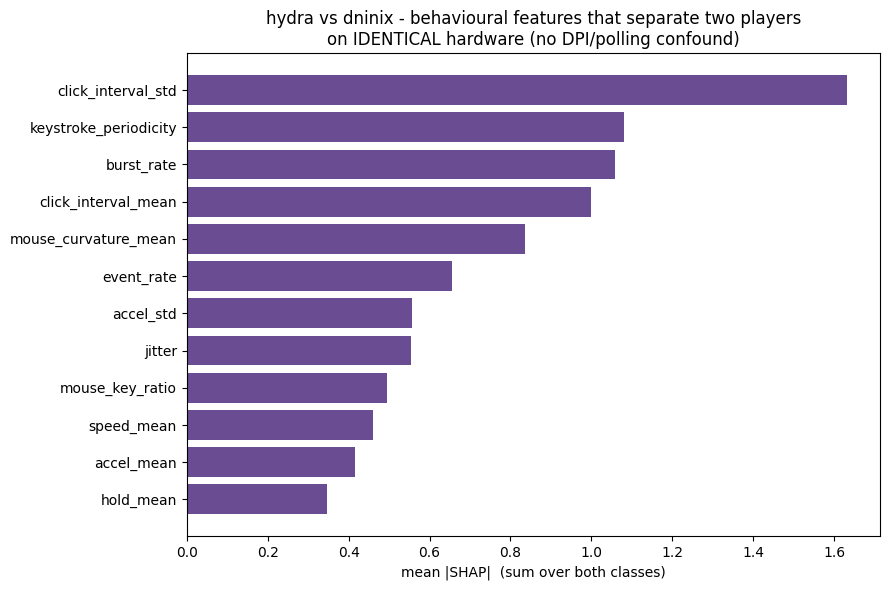

In [7]:
# Which features separate two players on identical hardware?
top = imp2.sort_values("total", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top.index, top["total"], color="#6a4c93")
ax.set_xlabel("mean |SHAP|  (sum over both classes)")
ax.set_title(
    "hydra vs dninix - behavioural features that separate two players\n"
    "on IDENTICAL hardware (no DPI/polling confound)"
)
fig.tight_layout()
fig.savefig(FIG / "phase5a_samehardware_shap.png", dpi=110, bbox_inches="tight")
plt.show()

**Why this matters for anti-cheat:** the 3-class number (test acc 0.85) was partly inflated by a third player on *different* hardware being trivially separable. Here, with hardware held constant, the model still distinguishes the two players — and SHAP names the exact behavioural features doing the work. That's the difference between "the model keys on a hardware fingerprint" and "the model learned a behavioural biometric."

## Part 4 — Explaining the LSTM-AE: per-channel reconstruction attribution

The autoencoder flags a 64-event chunk as cheat-like by **reconstructing it poorly**. The scalar score is the reconstruction MSE averaged over timesteps *and* the 8 input channels. Keep the per-channel breakdown and you get a direct answer to *which channel drove the flag*:

`dt, dx, dy, is_mouse_move, is_mouse_click_press, is_mouse_scroll, is_key_press, is_key_release`

We compare **legit** chunks against **triggerbot** cheat chunks (the strongest-detected cheat, chunk AUC 0.93).

In [8]:
from pipeline.models.lstm_ae import load_lstm_ae
from pipeline.sequences.preprocessing import apply_normalizer, session_to_event_tensor

ae, stats, meta = load_lstm_ae(ROOT / "models", device="cpu")
CH = int((meta.get("config") or {}).get("chunk_length", 64))
SYN = ROOT / "data" / "synthetic"


def chunks_and_flags(path):
    d = json.load(open(path))
    t = session_to_event_tensor(d)
    if len(t) < CH:
        return None, None
    n = len(t) // CH
    nm = apply_normalizer(t, stats)
    chunks = np.stack([nm[i * CH : (i + 1) * CH] for i in range(n)])
    flags = np.zeros(n, dtype=bool)
    segs = d.get("cheat_segments") or []
    if segs and d.get("events"):
        times = np.array([e.get("t", 0.0) for e in d["events"]])
        in_seg = np.zeros(len(times), dtype=bool)
        for a, b in segs:
            in_seg |= (times >= a) & (times <= b)
        for i in range(n):
            flags[i] = in_seg[i * CH : (i + 1) * CH].any()
    return chunks, flags


legit_rows, cheat_rows = [], []
for p in sorted(SYN.glob("*_legit.json")):
    c, _ = chunks_and_flags(p)
    if c is not None:
        legit_rows.append(per_channel_reconstruction_error(ae, c))
for p in sorted(SYN.glob("*_triggerbot.json")):
    c, f = chunks_and_flags(p)
    if c is not None and f.any():
        cheat_rows.append(per_channel_reconstruction_error(ae, c)[f])

legit_err = np.concatenate(legit_rows).mean(axis=0)
cheat_err = np.concatenate(cheat_rows).mean(axis=0)
pd.DataFrame(
    {
        "legit": legit_err,
        "triggerbot": cheat_err,
        "ratio": cheat_err / np.maximum(legit_err, 1e-9),
    },
    index=CHANNEL_NAMES,
).round(3)

,legit,triggerbot,ratio
dt,0.314,1.175,3.740
dx,0.212,0.090,0.426
dy,0.700,0.167,0.239
is_mouse_move,0.596,1.355,2.273
is_mouse_click_press,0.735,11.783,16.025
is_mouse_scroll,0.720,1.631,2.265
is_key_press,0.649,0.787,1.213
is_key_release,0.763,1.127,1.477


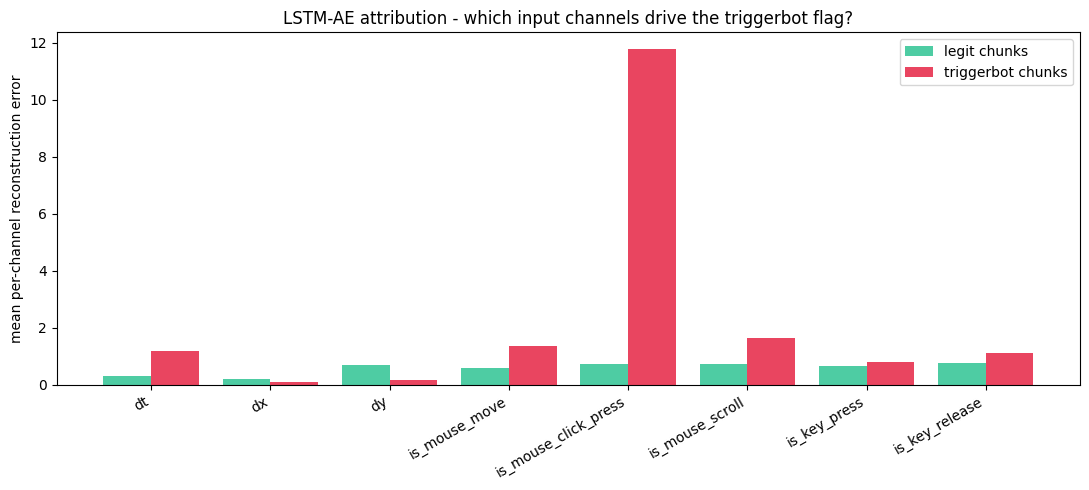

In [9]:
x = np.arange(len(CHANNEL_NAMES))
w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w / 2, legit_err, w, label="legit chunks", color="#4ecca3")
ax.bar(x + w / 2, cheat_err, w, label="triggerbot chunks", color="#e94560")
ax.set_xticks(x)
ax.set_xticklabels(CHANNEL_NAMES, rotation=30, ha="right")
ax.set_ylabel("mean per-channel reconstruction error")
ax.set_title("LSTM-AE attribution - which input channels drive the triggerbot flag?")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "phase5a_lstm_channel_attribution.png", dpi=110, bbox_inches="tight")
plt.show()

**Reading it:** the channels where the red bars tower over green are the ones the autoencoder couldn't reconstruct for cheat chunks — i.e. *what makes triggerbot look non-human at the millisecond level*. Triggerbot fires clicks with superhuman timing, so the click / timing channels light up. This is the per-detection explanation that would accompany a flag in production.

---

## Summary

- **Identification:** SHAP gives per-player feature fingerprints and per-decision audit trails. On **identical hardware** (hydra vs dninix) the model still separates players, and SHAP names the behavioural features doing it — a real biometric, not a hardware tell.
- **Cheat detection:** per-channel reconstruction error says *which raw input channel* drove each LSTM-AE flag — robust, exact, and free of SHAP-on-LSTM fragility.

**Caveats (honest):** 18 real sessions, 3 players — SHAP rankings are indicative, not definitive, at this scale; they'll sharpen with more recordings. Reusable code: `pipeline/explainability.py`. Figures saved under `reports/figures/phase5a_*.png`.